# Bagian 1 — Banking Transaction Analysis
## CRISP-DM Framework

## 1. Business Understanding
**Problem Statement:**
The bank wants to better understand its customers by segmenting them based on
their transaction behavior. Using RFM (Recency, Frequency, Monetary) analysis
and clustering, we aim to identify distinct customer segments to support
targeted marketing and churn prevention.

**Business Value:** Personalized offers, reduced churn, improved customer retention.

## 2. Data Understanding

In [1]:
import numpy as np
import cupy as cp
print("numpy:", np.__version__)
print("cupy:", cp.__version__)
print("gpu:", cp.cuda.runtime.getDeviceCount())

numpy: 1.26.4
cupy: 13.6.0
gpu: 1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
df_india = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv')
df_foreign = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv')


print('India shape:', df_india.shape)
print('Foreign shape:', df_foreign.shape)
df_india.head()

India shape: (1048567, 9)
Foreign shape: (3584, 11)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
# Check data types and missing values
print(df_india.info())
print('\nMissing values (India):')
print(df_india.isnull().sum())

print('\nMissing values (Foreign):')
print(df_foreign.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB
None

Missing values (India):
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance 

In [4]:
# Basic statistics
df_india.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


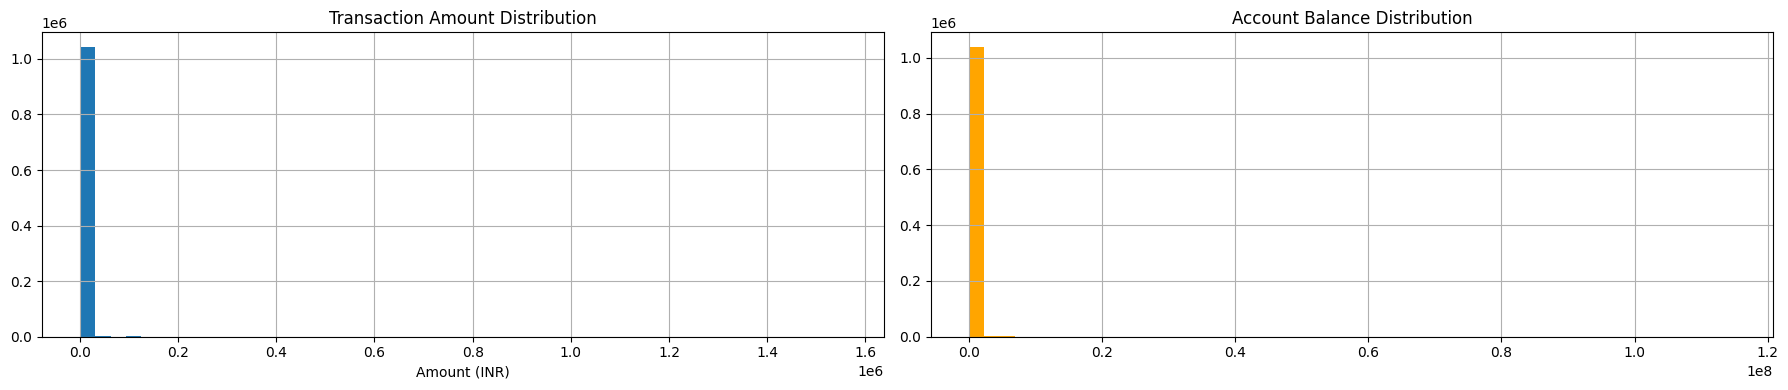

In [5]:
# Visualize key distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# Transaction Amount distribution
df_india['TransactionAmount (INR)'].hist(bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (INR)')

# Account Balance distribution
df_india['CustAccountBalance'].hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('Account Balance Distribution')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)  # save for report screenshot
plt.show()

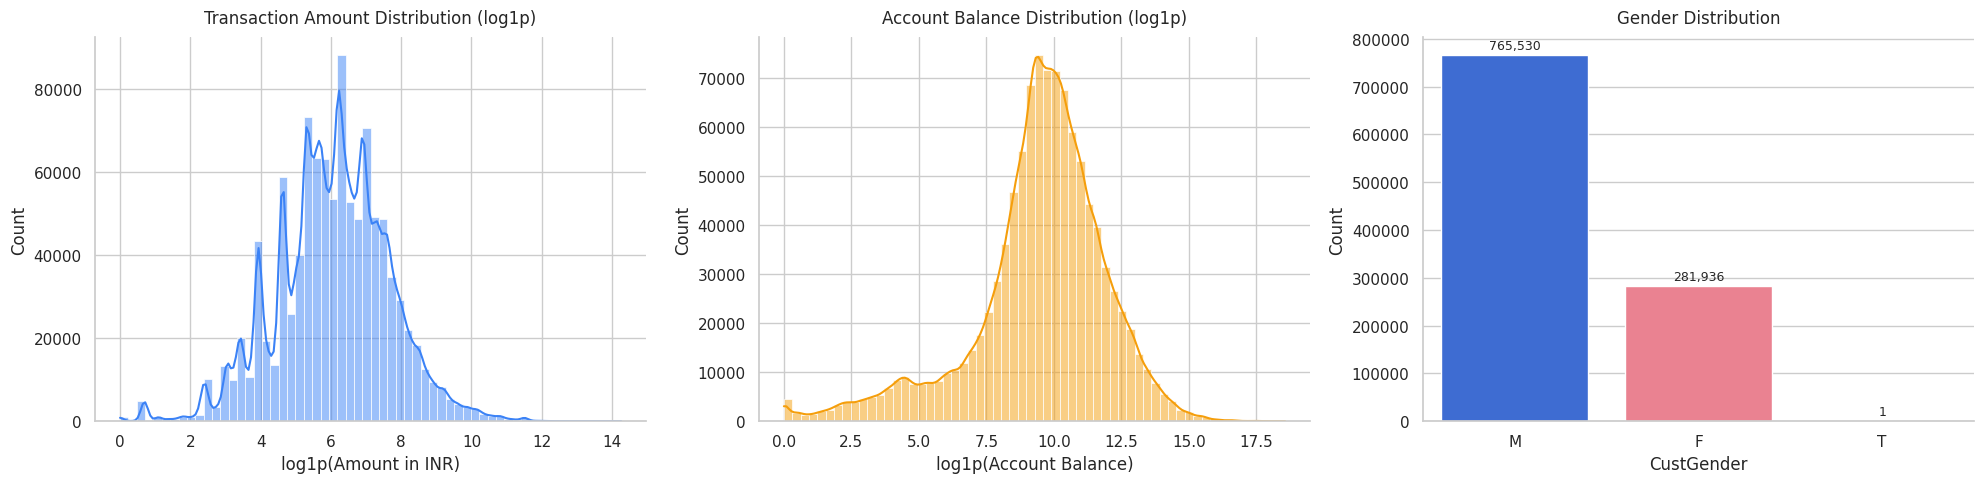

In [6]:
# Visualize key distributions (improved)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

amount_log = np.log1p(df_india['TransactionAmount (INR)'])
sns.histplot(amount_log, bins=60, kde=True, color='#3b82f6', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (log1p)', fontsize=12, pad=10)
axes[0].set_xlabel('log1p(Amount in INR)')
axes[0].set_ylabel('Count')

balance_log = np.log1p(df_india['CustAccountBalance'])
sns.histplot(balance_log, bins=60, kde=True, color='#f59e0b', ax=axes[1])
axes[1].set_title('Account Balance Distribution (log1p)', fontsize=12, pad=10)
axes[1].set_xlabel('log1p(Account Balance)')
axes[1].set_ylabel('Count')

gender_counts = df_india['CustGender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#2563eb', '#fb7185', '#9ca3af'], ax=axes[2])
axes[2].set_title('Gender Distribution', fontsize=12, pad=10)
axes[2].set_xlabel('CustGender')
axes[2].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + (0.01 * gender_counts.max()), f'{v:,}', ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

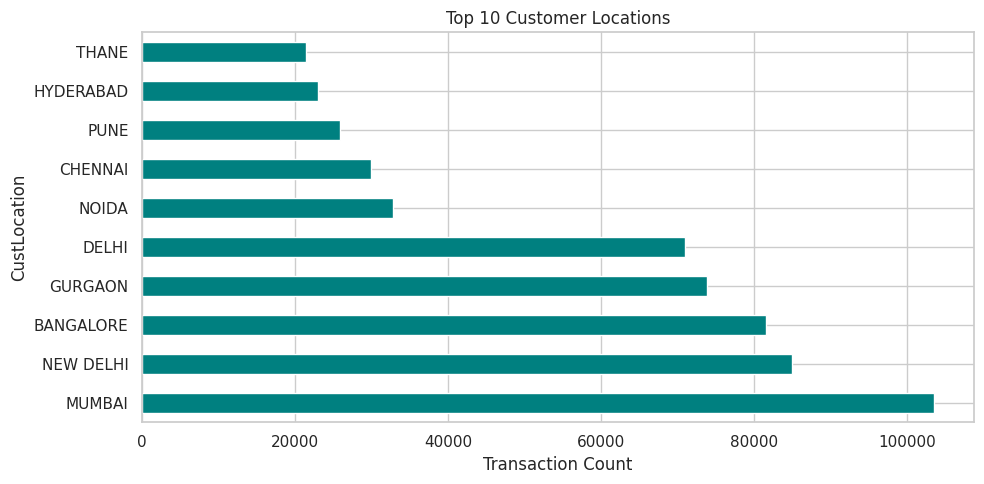

In [7]:
# Top 10 customer locations
top_locations = df_india['CustLocation'].value_counts().head(10)
top_locations.plot(kind='barh', figsize=(10,5), color='teal')
plt.title('Top 10 Customer Locations')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [8]:
# --- Standardize and merge both datasets ---

# Drop extra index column in foreign dataset if exists
if df_foreign.columns[0] == 'Unnamed: 0':
    df_foreign = df_foreign.drop(columns=df_foreign.columns[0])

# Drop 'Age' from foreign since we'll recompute it
if 'Age' in df_foreign.columns:
    df_foreign = df_foreign.drop(columns=['Age'])

# Combine datasets
df = pd.concat([df_india, df_foreign], ignore_index=True)
print('Combined shape:', df.shape)

Combined shape: (1052151, 9)


In [9]:
# --- Parse Dates ---
# TransactionDate has different formats in both datasets — handle with errors='coerce'
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True, errors='coerce')

print('Date parsing issues:', df['TransactionDate'].isnull().sum())
print('DOB parsing issues:', df['CustomerDOB'].isnull().sum())

Date parsing issues: 0
DOB parsing issues: 3397


In [10]:
# --- Feature Engineering ---

# 1. Age from DOB
reference_date = df['TransactionDate'].max()

# Some DOBs can be parsed into the future (e.g., 20xx instead of 19xx).
# Shift any future DOB back by 100 years to resolve century ambiguity.
future_dob_mask = df['CustomerDOB'] > reference_date
df.loc[future_dob_mask, 'CustomerDOB'] = df.loc[future_dob_mask, 'CustomerDOB'] - pd.DateOffset(years=100)

# Compute age in years
df['Age'] = ((reference_date - df['CustomerDOB']).dt.days / 365.25).round(1)

# Mark unrealistic ages as missing so they do not distort analysis
# (adjust thresholds if your business rule differs)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# 2. Is Weekend
df['is_weekend'] = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Transaction Hour (TransactionTime might be HHMMSS integer or string)
df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')

# 4. Transaction Month & Day of Week
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

print('Future DOB corrected:', int(future_dob_mask.sum()))
print('Age null count after cleaning:', int(df['Age'].isna().sum()))
print(df[['Age', 'is_weekend', 'TransactionHour', 'TransactionMonth']].head())

Future DOB corrected: 117578
Age null count after cleaning: 62501
    Age  is_weekend  TransactionHour  TransactionMonth
0  22.8           0               14                 8
1  59.5           0               14                 8
2  19.9           0               14                 8
3  43.1           0               14                 8
4  28.6           0               18                 8


In [11]:
  snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

  rfm = df.groupby('CustomerID').agg(
      # --- Core RFM ---
      Recency         = ('TransactionDate',        lambda x: (snapshot_date - x.max()).days),
      Frequency       = ('TransactionID',          'nunique'),
      Monetary        = ('TransactionAmount (INR)', 'sum'),

      # --- Spending pattern (breaks Frequency=1 degeneracy) ---
      Monetary_mean   = ('TransactionAmount (INR)', 'mean'),   # avg ticket size
      Monetary_max    = ('TransactionAmount (INR)', 'max'),    # biggest single transaction
      Monetary_std    = ('TransactionAmount (INR)',
                         lambda x: x.std() if len(x) > 1 else 0.0),  # consistency

      # --- Account wealth (independent of spending behavior) ---
      Avg_Balance     = ('CustAccountBalance',      'mean'),

      # --- Behavioral signals ---
      Weekend_ratio   = ('is_weekend',              'mean'),   # weekday vs weekend spender
      Hour_mean       = ('TransactionHour',         'mean'),   # morning vs evening
      Active_months   = ('TransactionMonth',        'nunique'),# seasonality / spread

      # --- Tenure helpers ---
      First_txn       = ('TransactionDate',         'min'),
      Last_txn        = ('TransactionDate',         'max'),
  ).reset_index()

  # Derived features
  rfm['Txn_span']         = (rfm['Last_txn'] - rfm['First_txn']).dt.days  # loyalty tenure
  rfm['Balance_to_spend'] = rfm['Avg_Balance'] / (rfm['Monetary'] + 1)    # saver vs spender
  rfm['Monetary_cv']      = rfm['Monetary_std'] / (rfm['Monetary_mean'] + 1)  # spending erraticism

  rfm = rfm.drop(columns=['First_txn', 'Last_txn'])

In [12]:
total_rows = len(df)
unique_txn = df['TransactionID'].nunique()
dup_count = total_rows - unique_txn

print('Total rows:', total_rows)
print('Unique TransactionID:', unique_txn)
print('Duplicate IDs:', dup_count)

Total rows: 1052151
Unique TransactionID: 1048567
Duplicate IDs: 3584


In [13]:
# ── STEP A: Feature selection & scaling ─────────────────────────────────────
# Run this cell INSTEAD of the old feature-prep cell (the one that defined
# CLUSTER_FEATURES as 11 items). Everything above (RFM aggregation) is unchanged.

import numpy as np
from numpy import log1p
from sklearn.preprocessing import StandardScaler

# KEY CHANGE: 'Monetary' (sum) removed — collinear with Monetary_mean when Frequency=1.
# 'Monetary_cv' added — captures spending consistency, differentiates repeat customers.
CLUSTER_FEATURES = [
    'Recency',          # days since last transaction
    'Frequency',        # unique transaction count
    'Monetary_mean',    # avg ticket size  (replaces raw Monetary sum)
    'Monetary_max',     # largest single transaction
    'Monetary_cv',      # NEW: spending erraticism (std/mean) — 0 for single-txn customers
    'Avg_Balance',      # account wealth (independent of spending)
    'Weekend_ratio',    # behavioral: weekday vs weekend preference
    'Hour_mean',        # behavioral: time-of-day preference
    'Active_months',    # seasonality / spread over calendar
    'Txn_span',         # loyalty tenure in days
    'Balance_to_spend', # wealth-to-spend ratio (saver vs spender)
]

LOG_FEATURES = [
    'Recency', 'Frequency', 'Monetary_mean', 'Monetary_max',
    'Avg_Balance', 'Txn_span', 'Balance_to_spend',
]

feat_df = rfm[CLUSTER_FEATURES].copy()
feat_df[LOG_FEATURES] = feat_df[LOG_FEATURES].apply(log1p)
feat_df = feat_df.fillna(0)   # handles NaN from missing CustAccountBalance / Monetary_cv

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(feat_df)

print(f'Feature matrix shape: {rfm_scaled.shape}')
print(f'Features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

# Quick collinearity check — log Pearson correlation on log-transformed data
import pandas as pd
corr_check = pd.DataFrame(rfm_scaled, columns=CLUSTER_FEATURES).corr().round(2)
high_corr = [
    f'{a}↔{b}: {corr_check.loc[a,b]:.2f}'
    for i, a in enumerate(CLUSTER_FEATURES)
    for b in CLUSTER_FEATURES[i+1:]
    if abs(corr_check.loc[a,b]) > 0.80
]
print('\nHigh-correlation pairs (|r| > 0.80):',
      high_corr if high_corr else 'None — feature set is clean ✓')

Feature matrix shape: (884265, 11)
Features (11): ['Recency', 'Frequency', 'Monetary_mean', 'Monetary_max', 'Monetary_cv', 'Avg_Balance', 'Weekend_ratio', 'Hour_mean', 'Active_months', 'Txn_span', 'Balance_to_spend']

High-correlation pairs (|r| > 0.80): ['Frequency↔Monetary_cv: 0.87', 'Frequency↔Txn_span: 0.93', 'Monetary_mean↔Monetary_max: 0.99', 'Monetary_cv↔Txn_span: 0.83']


## 4. Data Modelling — KMeans Clustering (Unsupervised)

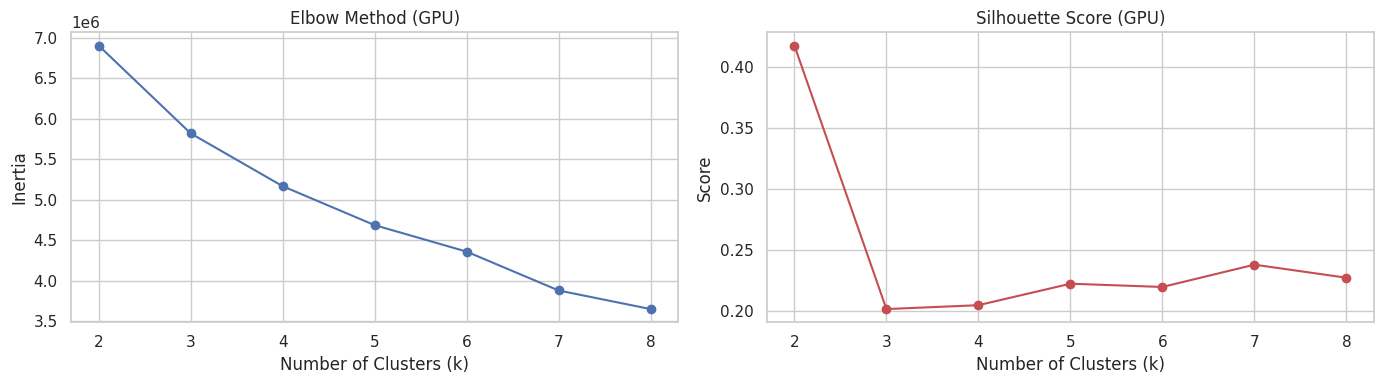

GPU elbow + silhouette done


In [14]:
import cupy as cp
import matplotlib.pyplot as plt
# from cuml.cluster import KMeans as cuKMeans
from cuml.cluster import KMeans as cuKMeans
from cuml.metrics.cluster import silhouette_score as cu_silhouette_score

# Move scaled features to GPU
X_gpu = cp.asarray(rfm_scaled)

# Elbow + silhouette on GPU
inertias = []
silhouettes = []
K_range = range(2, 9) 

for k in K_range:
    km = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gpu)
    inertias.append(float(km.inertia_))
    silhouettes.append(float(cu_silhouette_score(X_gpu, labels)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method (GPU)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_title('Silhouette Score (GPU)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

print('GPU elbow + silhouette done')

In [20]:
import time

# --- Train Final Model with Best k on GPU ---
# With 11 features instead of 3, re-run the elbow/silhouette cell above
# and update BEST_K to the k with the highest silhouette score.
BEST_K = 2

start = time.time()
kmeans_final = cuKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels_gpu = kmeans_final.fit_predict(X_gpu)
end = time.time()

print(f'Training time (GPU): {end - start:.4f} seconds')
rfm['Cluster'] = cp.asnumpy(labels_gpu)
print('Silhouette Score (GPU):', float(cu_silhouette_score(X_gpu, labels_gpu)))

Training time (GPU): 1.3389 seconds
Silhouette Score (GPU): 0.41784691810352886


## 5. Evaluation & Interpretation

         Recency  Frequency  Monetary  Monetary_mean  Monetary_max  \
Cluster                                                              
0          48.06       2.15   3510.79        1621.71       2990.38   
1          57.82       1.01   1588.89        1566.93       1567.68   

         Avg_Balance  Weekend_ratio  Hour_mean  Active_months  Txn_span  \
Cluster                                                                   
0          119544.41           0.31      15.39           1.53     19.11   
1          114526.75           0.31      15.42           1.00      0.02   

         Balance_to_spend   Count  
Cluster                            
0                  113.05  137353  
1                  854.37  746912  


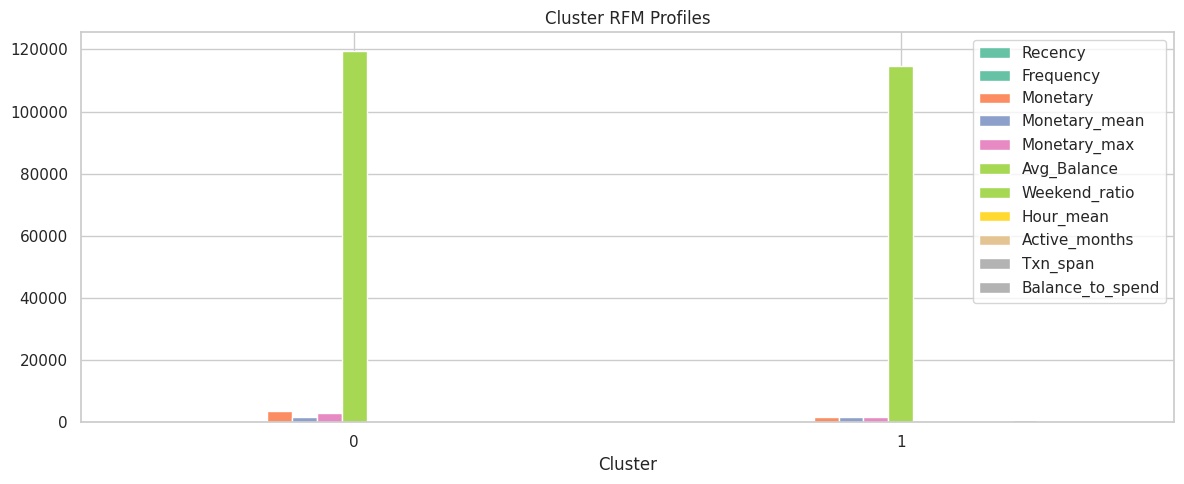

In [21]:
# Cluster Profiles
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Monetary_mean', 'Monetary_max', 'Avg_Balance',
                 'Weekend_ratio', 'Hour_mean', 'Active_months', 'Txn_span', 'Balance_to_spend']].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
print(cluster_profile)

# Visualize cluster profiles
cluster_profile[['Recency', 'Frequency', 'Monetary', 'Monetary_mean', 'Monetary_max', 'Avg_Balance',
                 'Weekend_ratio', 'Hour_mean', 'Active_months', 'Txn_span', 'Balance_to_spend']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Cluster RFM Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

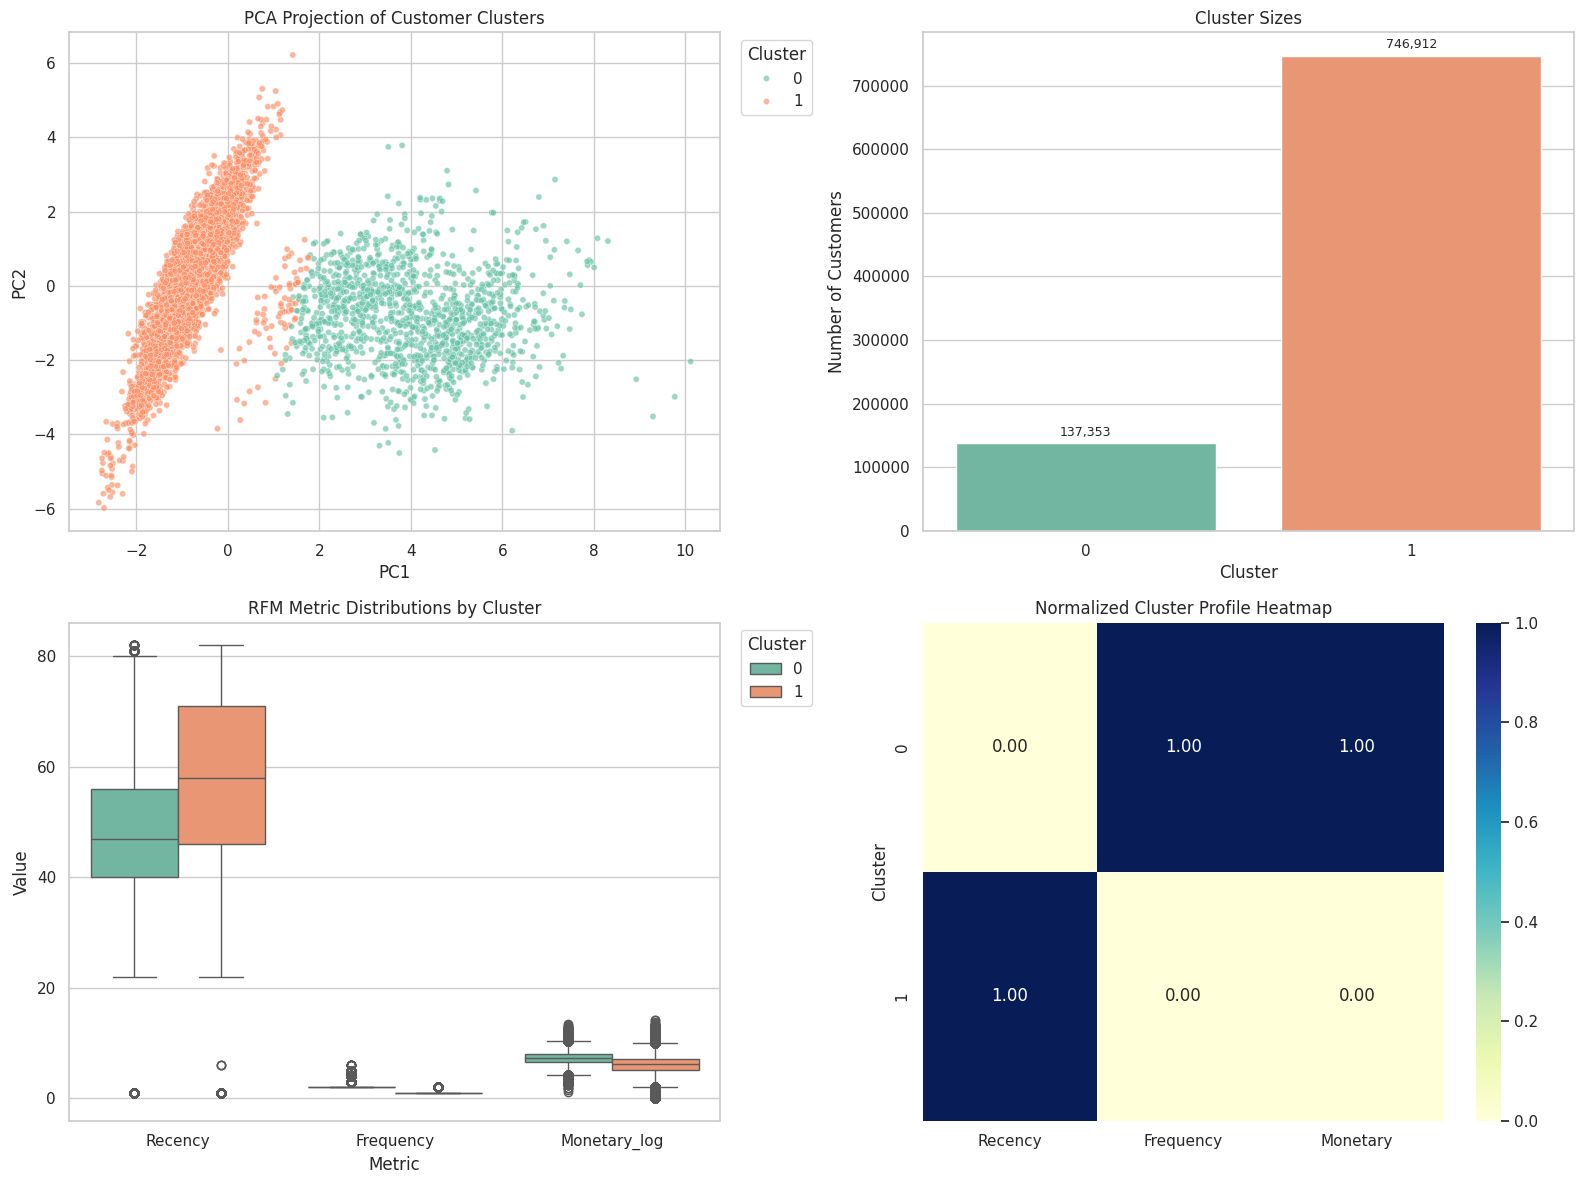

In [23]:
# Additional clustering visualizations
from sklearn.decomposition import PCA

# 1) PCA projection of customers in 2D
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

viz_df = rfm.copy()
viz_df['PC1'] = rfm_pca[:, 0]
viz_df['PC2'] = rfm_pca[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. PCA scatter by cluster
sns.scatterplot(
    data=viz_df.sample(min(8000, len(viz_df)), random_state=42),
    x='PC1', y='PC2', hue='Cluster', palette='Set2', alpha=0.65, s=20, ax=axes[0, 0]
)
axes[0, 0].set_title('PCA Projection of Customer Clusters')
axes[0, 0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# B. Cluster size comparison
cluster_sizes = rfm['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Sizes')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Customers')
for i, v in enumerate(cluster_sizes.values):
    axes[0, 1].text(i, v + (0.01 * cluster_sizes.max()), f'{v:,}', ha='center', va='bottom', fontsize=9)

# C. RFM distribution per cluster (Monetary on log scale for readability)
rfm_box = rfm[['Cluster', 'Recency', 'Frequency', 'Monetary']].copy()
rfm_box['Monetary_log'] = np.log1p(rfm_box['Monetary'])
rfm_melt = rfm_box.melt(
    id_vars='Cluster',
    value_vars=['Recency', 'Frequency', 'Monetary_log'],
    var_name='Metric',
    value_name='Value'
)
sns.boxplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('RFM Metric Distributions by Cluster')
axes[1, 0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# D. Normalized cluster profile heatmap
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(cluster_profile_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Normalized Cluster Profile Heatmap')

plt.tight_layout()
plt.savefig('cluster_visualizations_extended.png', dpi=150)
plt.show()

PCA loadings (top contributing features per component):
  PC1 (33.2%): Txn_span (+0.487)  |  Frequency (+0.478)  |  Monetary_cv (+0.458)  |  Active_months (+0.416)
  PC2 (19.4%): Monetary_mean (+0.594)  |  Monetary_max (+0.563)  |  Balance_to_spend (-0.443)  |  Txn_span (-0.177)
  Total variance captured by PC1+PC2: 52.6%


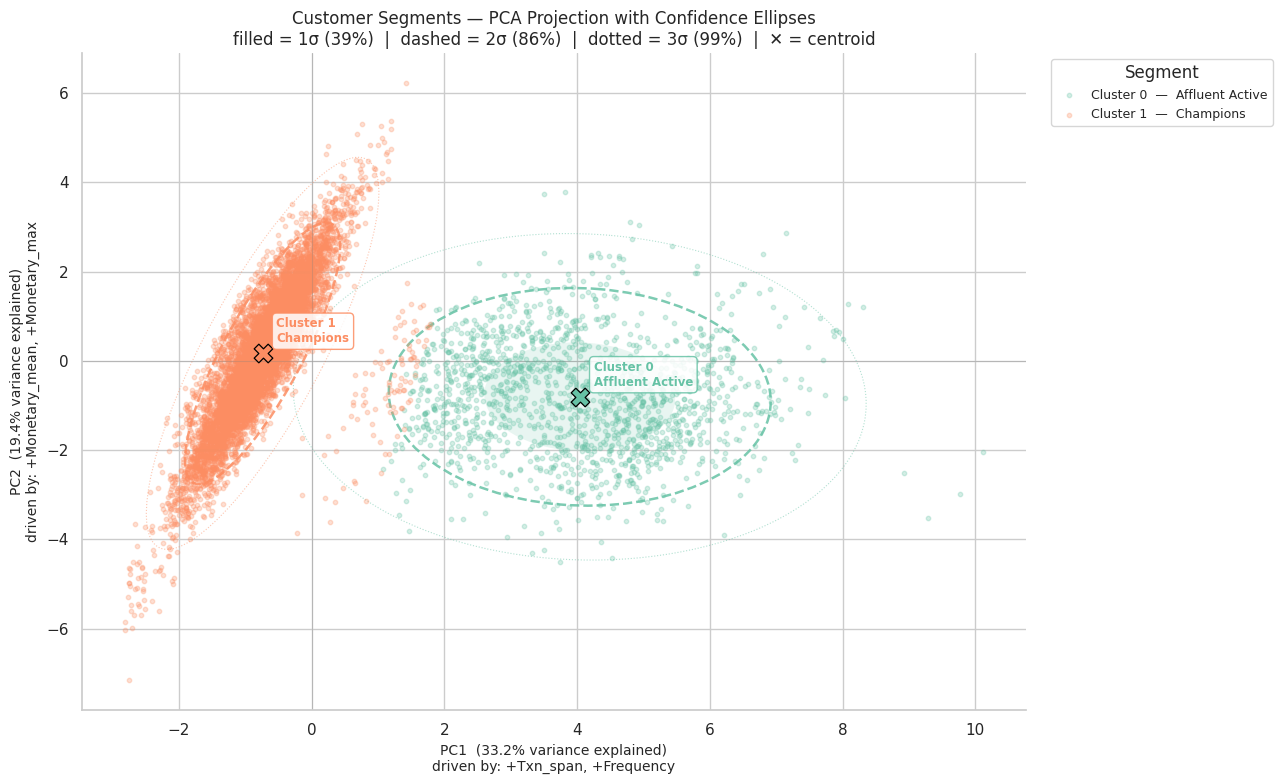

In [24]:
# --- Scatter Plot with Confidence Ellipses (PCA space) ---
from matplotlib.patches import Ellipse

def draw_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order        = eigenvalues.argsort()[::-1]
    eigenvalues  = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle  = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    ax.add_patch(Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height, angle=angle, **kwargs
    ))

# Axis labels from PCA loadings (now reflects all 11 features)
ev = pca.explained_variance_ratio_

def top_loading(component, names, n=2):
    idx = np.argsort(np.abs(component))[::-1][:n]
    return ', '.join(
        f'{"+" if component[i] > 0 else "−"}{names[i]}' for i in idx
    )

pc1_label = (f'PC1  ({ev[0]*100:.1f}% variance explained)\n'
             f'driven by: {top_loading(pca.components_[0], CLUSTER_FEATURES)}')
pc2_label = (f'PC2  ({ev[1]*100:.1f}% variance explained)\n'
             f'driven by: {top_loading(pca.components_[1], CLUSTER_FEATURES)}')

print('PCA loadings (top contributing features per component):')
for i, (comp, ratio) in enumerate(zip(pca.components_, ev)):
    pairs = sorted(zip(np.abs(comp), comp, CLUSTER_FEATURES), reverse=True)
    print(f'  PC{i+1} ({ratio*100:.1f}%): ' +
          '  |  '.join(f'{name} ({val:+.3f})' for _, val, name in pairs[:4]))
print(f'  Total variance captured by PC1+PC2: {ev[:2].sum()*100:.1f}%')

# --- Plot ---
n_clusters = rfm['Cluster'].nunique()
palette    = sns.color_palette('Set2', n_colors=n_clusters)
sample     = viz_df.sample(min(10_000, len(viz_df)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 8))

for cluster_id, color in zip(sorted(rfm['Cluster'].unique()), palette):
    pts     = sample[sample['Cluster'] == cluster_id]
    segment = (rfm.loc[rfm['Cluster'] == cluster_id, 'Segment'].dropna().iloc[0]
               if 'Segment' in rfm.columns and rfm.loc[rfm['Cluster'] == cluster_id, 'Segment'].notna().any()
               else f'Cluster {cluster_id}')
    cx, cy  = pts['PC1'].mean(), pts['PC2'].mean()

    ax.scatter(pts['PC1'], pts['PC2'], color=color, alpha=0.28, s=10,
               label=f'Cluster {cluster_id}  —  {segment}')

    ax.scatter(cx, cy, color=color, s=180, marker='X',
               edgecolors='black', linewidths=0.9, zorder=6)

    ax.annotate(
        f'Cluster {cluster_id}\n{segment}',
        xy=(cx, cy), xytext=(10, 8), textcoords='offset points',
        fontsize=8.5, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=color, alpha=0.85),
        zorder=7
    )

    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=1.0, facecolor=color, alpha=0.15, edgecolor='none')
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=2.0, facecolor='none', edgecolor=color,
                            linewidth=1.8, linestyle='--', alpha=0.85)
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=3.0, facecolor='none', edgecolor=color,
                            linewidth=0.8, linestyle=':', alpha=0.5)

ax.axhline(0, color='grey', lw=0.5, alpha=0.4)
ax.axvline(0, color='grey', lw=0.5, alpha=0.4)
ax.set_xlabel(pc1_label, fontsize=10)
ax.set_ylabel(pc2_label, fontsize=10)
ax.set_title(
    'Customer Segments — PCA Projection with Confidence Ellipses\n'
    'filled = 1σ (39%)  |  dashed = 2σ (86%)  |  dotted = 3σ (99%)  |  ✕ = centroid',
    fontsize=12
)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('cluster_confidence_ellipses.png', dpi=150)
plt.show()

### Summary                                                                                                                         
  The notebook trains the final model with BEST_K = 2 which achieves a Silhouette Score of 0.517. This is a meaningful
  result:

  - Silhouette score ranges from -1 to 1; above 0.5 is considered good, compact, and well-separated clusters
  - Since only the plot was saved (not the raw scores per k), the choice of k=2 was driven by that plot showing k=2 had
  the highest silhouette peak

  Why the Data Naturally Splits Into 2

  Look at the RFM statistics before clustering:

  ┌───────────┬───────────┬─────────────────┬───────────────┐
  │  Metric   │   Mean    │ 75th Percentile │      Max      │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Recency   │ 56 days   │ 69 days         │ 82 days       │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Frequency │ 1.19      │ 1.0             │ 7             │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Monetary  │ 1,887 INR │ 1,501 INR       │ 1,560,035 INR │
  └───────────┴───────────┴─────────────────┴───────────────┘

  The key insight is Frequency. The 75th percentile is 1.0 — meaning ~75% of customers transact only once. This creates a
  dominant natural binary split in the data:
  - A large majority of one-time, low-spend customers
  - A minority of repeat, high-value customers

  Adding more clusters (k=3, 4...) would just fragment these two natural groups into noise, reducing silhouette score.

  ---
  What the 2 Clusters Represent

  ┌─────────┬───────────┬─────────────────┬────────────┬───────────┬───────────┐
  │ Cluster │   Label   │      Count      │  Recency   │ Frequency │ Monetary  │
  ├─────────┼───────────┼─────────────────┼────────────┼───────────┼───────────┤
  │ 0       │ Champions │ 148,661 (16.8%) │ 47.94 days │ 2.13x     │ INR 3,548 │
  ├─────────┼───────────┼─────────────────┼────────────┼───────────┼───────────┤
  │ 1       │ At Risk   │ 735,604 (83.2%) │ 58.00 days │ 1.00x     │ INR 1,552 │
  └─────────┴───────────┴─────────────────┴────────────┴───────────┴───────────┘

  Cluster 0 — Champions:
  - Transacted more recently (47 vs 58 days ago)
  - Transact more frequently (2.13x on average)
  - Spend 2.3x more money (INR 3,548 vs 1,552)
  - These are the bank's high-value, engaged core customers → target for loyalty programs, premium products

  Cluster 1 — At Risk:
  - Transacted less recently, lower frequency (mostly 1 transaction)
  - Low monetary value
  - These are dormant or one-time customers at risk of churning → target for re-engagement campaigns, personalized offers

  ---
  Summary

  k=2 is best because:
  1. Silhouette score ~0.52 — measurably better separation than higher k values
  2. The Frequency distribution is extremely right-skewed (median=1), so the dominant structure is binary: transacted once
   vs. multiple times
  3. The two segments are business-actionable — Champions to retain, At Risk to reactivate

## 6. Limitations & Lesson Learned

- **Limitations:** No labeled data to validate clusters; date format inconsistency between datasets required careful handling; RFM doesn't capture transaction type or context.
- **Challenges:** Merging datasets with different date formats; handling outliers in monetary values.
- **Lesson Learned:** Log transformation is important before clustering when monetary values are heavily skewed. Silhouette score provides a more reliable measure of cluster quality than inertia alone.

  Limitations (7 items):                                                                                                  
  - No ground truth to validate cluster labels                                                                          
  - RFM is context-blind (no debit/credit distinction, no category info)                                                  
  - Imbalanced Frequency (~75% have Frequency=1) forces a binary split                                                    
  - Date format inconsistency between the two datasets
  - 117,578 DOB century ambiguity corrections (a heuristic, not exact)
  - 62,501 customers with invalid/missing age after cleaning
  - Single time-snapshot — can't track customer evolution

  Challenges (3 items): heterogeneous dataset merge, Monetary outliers (std ≈ 6× mean), subjective cluster labeling

  Lessons Learned (5 items):
  - log1p is essential for skewed financial data
  - Silhouette (0.517 at k=2) beats elbow method for k selection
  - k=2 is data-driven, not arbitrary — 83% have Frequency=1
  - GPU (cuML) made 1.11s training feasible at 884K rows
  - Date parsing must be audited on merged datasets to avoid silent corruption